Abruf von externen Daten

In [91]:
import ssl
import time
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from urllib.request import urlopen

import certifi
import pandas as pd
from lxml import html as lxml_html

In [2]:
url = "https://schuldatenbank.sachsen.de/index.php?id=110&institution_key=4233037"

context = ssl.create_default_context(cafile=certifi.where())

In [3]:
with urlopen(url, timeout=10, context=context) as response:
    html = response.read().decode("utf-8")

tabellen = pd.read_html(StringIO(html))

len(tabellen)

9

Struktur der gefundenen Tabellen ansehen (Ausgabe wird von VScode abgeschnitten):

In [4]:
for i, tabelle in enumerate(tabellen):
    print(f"Tabelle {i}:")
    print(tabelle.head(3))
    print()

Tabelle 0:
  Klassenstufe  Durchschnittliche Klassenstärke*  Anzahl
0            5                              24.5      49
1            6                              27.5      55
2            7                              24.3      73

Tabelle 1:
  Klassenstufe  Durchschnittliche Klassenstärke*  Anzahl
0            5                              27.0      54
1            6                              26.0      52
2            7                              23.0      69

Tabelle 2:
  Art der Beschäftigung Beschäftigungsumfang
0        Hausmeister/in         42 h / Woche
1     Sachbearbeiter/in         35 h / Woche

Tabelle 3:
              Art der Beschäftigung  \
0  Sozialarbeiter / Sozialpädagogen   
1                          Sonstige   
2          Berufseinstiegsbegleiter   

                                           Tätigkeit  \
0                              Schulsozialarbeiterin   
1                                     Schulassistenz   
2  Berufseinstiegsbegleiterin für uns

In allen 9 Tabelle nach "Realschulabschluss" suchen:

In [5]:
for i, tabelle in enumerate(tabellen):
    if tabelle.astype(str).apply(
        lambda spalte: spalte.str.contains(
            "Realschulabschluss",
            case=False,
            na=False,
        ).any()
    ).any():
        print(f"Treffer in Tabelle {i}")

Treffer in Tabelle 6


Ergebnis: Tabelle 6 enthält damit die Schulabschlüsse.

In [6]:
tabellen[6]

,Abschluss,Gesamt,Anteil in %
0,Abgangszeugnis,8,13.6
1,Hauptschulabschluss,4,6.8
2,Qualifizierendem Hauptschulabschluss,2,3.4
3,Realschulabschluss,45,76.3


Schuljahr im geladenen HTML suchen, um dann gezielt diese Schuljahre an allen 380 Schulen abzurufen.

In [7]:
"2024/25" in html, "2023/24" in html

(True, False)

Ergebnis: Im aktuell geladenen HTML steckt nur 2024/25, nicht 2023/24.

In [8]:
position = html.find("2024/25")

print(html[position - 500 : position + 500])

ontent-1-1">
<ul class="nav nav-tabs" role="tablist">
<li role="presentation">
<a href="#tablist-1_tab-1" class="tab-head" aria-controls="tablist-1_tab-1" role="tab" data-toggle="tab">
2026/27
</a>
</li>
<li role="presentation" class="active">
<a href="#tablist-1_tab-2" class="tab-head" aria-controls="tablist-1_tab-2" role="tab" data-toggle="tab">
2025/26
</a>
</li>
<li role="presentation">
<a href="#tablist-1_tab-3" class="tab-head" aria-controls="tablist-1_tab-3" role="tab" data-toggle="tab">
2024/25
</a>
</li>
</ul>
<div class="tab-content">
<div role="tabpanel" class="tab-pane"id=tablist-1_tab-1>
<h2>Nach Klassenstufe</h2>
<p>Es liegen keine Daten vor</p>
<h2>Klassenwiederholung</h2>
Es liegen keine Daten vor
</div>
<div role="tabpanel" class="tab-pane active"id=tablist-1_tab-2>
<h2>Nach Klassenstufe</h2>
<table class='table-center'>
<thead>
<tr>
<th>Klassenstufe</th>
<th>Durchschnittliche Klassenstärke*</th>
<th>Anzahl</th>
</tr>
</thead>
<tbody>
<tr>
<td>5</td>
<td>24.5</td>
<td>

In [9]:
baum = lxml_html.fromstring(html)

for tab in baum.xpath('//div[contains(@class, "tab-pane")]'):
    text = " ".join(tab.itertext())

    if "Realschulabschluss" in text:
        print("Tab-ID:", tab.get("id"))
        print(text[:1000])

Tab-ID: tablist-2_tab-3

 Nach Abschluss 
Mit Beendigung der Vollzeitschulpflicht mit:
 
 
 
 Abschluss 
 Gesamt 
 Anteil in % 
 
 
 
 Abgangszeugnis 
 8 
 13.6 
 
 
 Hauptschulabschluss 
 4 
 6.8 
 
 
 Qualifizierendem Hauptschulabschluss 
 2 
 3.4 
 
 
 Realschulabschluss 
 45 
 76.3 
 
 
 
 Quelle: Statistisches Landesamt Amtliche Schulstatistik 2024/2025, Stand: 02.10.2024 
 Nach Prüfungsergebnis 
 
 
 
 Prüfungsnotenmittelwert 
 Schule 
 Oberschulen im Aufsichtsbezirk Chemnitz 
 Oberschulen in Sachsen 
 
 
 
 
 Mathematik 
 4.8 
 3.8 
 3.9 
 
 
 Deutsch 
 3.3 
 3.1 
 3.1 
 
 
 Bestehensquote in % 
 92.0 
 96.0 
 96.0 
 
 
 
 Quelle: Meldung durch Schulaufsichtsbehörden, Stand: 27.06.2025 



Abschlusstabelle damit technisch eindeutig gefunden: Sie liegt in tablist-2_tab-3. Nächster Schritt: Schuljahre von tablist-2 auslesen: 

In [10]:
for link in baum.xpath('//a[starts-with(@href, "#tablist-2_tab-")]'):
    print(link.get("href"), "→", link.text_content().strip())

#tablist-2_tab-1 → 2026/27
#tablist-2_tab-2 → 2025/26
#tablist-2_tab-3 → 2024/25


Jetzt testen, ob der jeweilige Schuljahres-Tab Abschlussdaten enthält:

In [11]:
tab_zu_schuljahr = {
    "tablist-2_tab-1": "2026/27",
    "tablist-2_tab-2": "2025/26",
    "tablist-2_tab-3": "2024/25",
}

for tab_id, schuljahr in tab_zu_schuljahr.items():
    tab = baum.get_element_by_id(tab_id)
    text = " ".join(tab.itertext())

    hat_abschlussdaten = "Realschulabschluss" in text

    print(schuljahr, "→", hat_abschlussdaten)

2026/27 → False
2025/26 → False
2024/25 → True


Jetzt zur Sicherheit noch beispielhaft eine zweite Schule testen und dafür gezielt zwei IDs aus der eigenen schulen(1).csv verwenden. z. B. die Aktive Schule Leipzig – Freie Oberschule; sie ist in der Schuldatenbank eindeutig als freie Trägerschaft ausgewiesen. Ihr Dienststellenschlüssel lautet 4431615:

Prüfe jetzt bei dieser freien Oberschule, ob für 2024/25 tatsächlich Abschlussdaten vorhanden sind:

In [12]:
for tab_id, schuljahr in {
    "tablist-2_tab-1": "2026/27",
    "tablist-2_tab-2": "2025/26",
    "tablist-2_tab-3": "2024/25",
}.items():
    tab = baum.get_element_by_id(tab_id)
    text = " ".join(tab.itertext())

    hat_abschlussdaten = "Realschulabschluss" in text

    print(schuljahr, "→", hat_abschlussdaten)

2026/27 → False
2025/26 → False
2024/25 → True


Damit ist der technische Test an einer öffentlichen und einer freien Oberschule erfolgreich:

beide Seiten verwenden dieselbe Schuljahrstruktur,
Abschlussdaten sind jeweils für 2024/25 vorhanden,
für 2025/26 und 2026/27 noch nicht,
die Anzahl der HTML-Tabellen variiert jedoch (9 vs. 7).

## Nächster Schritt: Abschlussdaten aus 2024/25 gezielt mit Hilfe einer Funktion extrahieren

In [13]:
def extrahiere_abschluesse_2024_25(baum):
    tab = baum.get_element_by_id("tablist-2_tab-3")

    tabellen_im_tab = tab.xpath(".//table")

    if not tabellen_im_tab:
        return None

    html_tabelle = lxml_html.tostring(
        tabellen_im_tab[0],
        encoding="unicode",
    )

    return pd.read_html(StringIO(html_tabelle))[0]

Die Funktion macht drei Dinge:

Sie greift direkt auf tablist-2_tab-3 → 2024/25 zu.
Sie sucht nur innerhalb dieses Tabs nach einer Tabelle.
Wenn keine Tabelle vorhanden ist, gibt sie None zurück, statt einen Fehler zu erzeugen.

Testen der Funktion:

In [14]:
df_test_abschluesse = extrahiere_abschluesse_2024_25(baum)

df_test_abschluesse

,Abschluss,Gesamt,Anteil in %
0,Abgangszeugnis,8,13.6
1,Hauptschulabschluss,4,6.8
2,Qualifizierendem Hauptschulabschluss,2,3.4
3,Realschulabschluss,45,76.3


Jetzt Funktion an der ersten Testschule gegenprüfen (dazu wurde die url oben geändert!):

In [15]:
with urlopen(url, timeout=10, context=context) as response:
    html = response.read().decode("utf-8")

baum = lxml_html.fromstring(html)

df_test_abschluesse = extrahiere_abschluesse_2024_25(baum)

df_test_abschluesse

,Abschluss,Gesamt,Anteil in %
0,Abgangszeugnis,8,13.6
1,Hauptschulabschluss,4,6.8
2,Qualifizierendem Hauptschulabschluss,2,3.4
3,Realschulabschluss,45,76.3


Test erfolgreich --> es kann zum automatisierten Abruf übergegangen werden. Zuvor soll noch die bereits exportierte schulen (1).csv im Notebook eingelesen und ihre Struktur geprüft werden. Sie soll später unsere Liste der abzurufenden Schul-IDs und die Trägerinformationen liefern.

## Einlesen der Daten aus oberschulen_schuldatenbank.csv (ehemalig schulen (1)):

In [16]:
df_schulen = pd.read_csv(
    "../data/raw/oberschulen_schuldatenbank.csv"
)

display(df_schulen.head())
df_schulen.info()

,id,name,owner_id,owner_abbreviation,owner_name,owner_type
0,280,"1. Oberschule Großenhain ""Am Kupferberg""",402,NaN,Stadt Großenhain,15
1,2158,1. Oberschule Kamenz,833,NaN,Landkreis Bautzen,16
2,485,"101. Oberschule ""Johannes Gutenberg""",874,NaN,Stadt Dresden,14
3,3763,107. Oberschule Dresden,874,NaN,Stadt Dresden,14
4,584,116. Oberschule Dresden,874,NaN,Stadt Dresden,14


<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  380 non-null    int64
 1   name                380 non-null    str  
 2   owner_id            380 non-null    int64
 3   owner_abbreviation  93 non-null     str  
 4   owner_name          380 non-null    str  
 5   owner_type          380 non-null    int64
dtypes: int64(3), str(3)
memory usage: 17.9 KB


Vorabprüfung. ob Schulen doppelt enthalten sind:

In [17]:
df_schulen["id"].duplicated().sum()

np.int64(0)

Prüfung der vorhandenen Trägerarten:

In [18]:
df_schulen["owner_type"].value_counts().sort_index()

owner_type
11     1
12    42
13    73
14    72
15    87
16    12
18     1
20    20
21    16
22    36
29    20
Name: count, dtype: int64

Ergebnis: 
11 Trägerarten Auffällig: 
11-18-->288 Schulen
20-29--> 92 Schulen (vermutlich erste Gruppe öffentlich und zweite Gruppe freier Träger)

Nächster Schritt: Beispiele ansehen für "owner_type" und "owner_name"

In [19]:
df_schulen.groupby("owner_type")["owner_name"].first()

owner_type
11    Freistaat Sachsen - Staatsministerium für Wiss...
12                                  Gemeinde Kodersdorf
13                          Stadt Ebersbach-Neugersdorf
14                                        Stadt Dresden
15                                     Stadt Großenhain
16                                    Landkreis Bautzen
18                           Schulverband Treuener Land
20    Kinderbetreuungs- und Bildungsträger St. Egidi...
21                                Bistum Dresden-Meißen
22                                       epharisto e.V.
29    Gemeinnützige Gesellschaft Semper Bildungswerk...
Name: owner_name, dtype: str

Plausibilitätscheck mit deinem bestehenden Datensatz zur Zahl öffentlicher und freier Oberschulen "oberschulen_sachsen_oeffentlich_vs_frei.csv"

Öffentliche und freie Oberschulen desselben Schuljahres nebeneinander:

In [20]:
df_schulzahlen.loc[
    df_schulzahlen["schuljahr"] == "2024/2025",
    ["schuljahr", "traegerschaft", "schulen"]
]

NameError: name 'df_schulzahlen' is not defined

Owner_id prüfen um eine Zuordnungsmöglichkeit von öffentlicher und freier Schule zu finden:

In [ ]:
df_schulen.loc[0, ["name", "owner_id", "owner_name", "owner_type"]]

name          1. Oberschule Großenhain "Am Kupferberg"
owner_id                                           402
owner_name                            Stadt Großenhain
owner_type                                          15
Name: 0, dtype: object

In [ ]:
owner_id = 402

owner_url = (
    "https://schuldatenbank.sachsen.de/"
    f"index.php?id=20&k_tid={owner_id}"
)

with urlopen(owner_url, timeout=10, context=context) as response:
    owner_html = response.read().decode("utf-8")

print("öffentlicher Träger" in owner_html)
print("freier Träger" in owner_html)

True
False


Ergebnis: Die owner_id führt uns also tatsächlich zur offiziellen Trägerseite, und die Rechtsstellung lässt sich aus dem HTML auslesen.

Jetzt owner_id testen die zu einer freien Schule passt:

In [ ]:
df_schulen.loc[
    df_schulen["owner_type"].isin([20, 21, 22, 29]),
    ["name", "owner_id", "owner_name", "owner_type"],
].head()

,name,owner_id,owner_name,owner_type
32,Achatschule St. Egidien-Oberschule mit Berufso...,6046,Kinderbetreuungs- und Bildungsträger St. Egidi...,20
34,AHFOberschule Markkleeberg (Schule in freier T...,6067,AHFSchulverein e. V.,20
35,Aktive Schule Leipzig - Freie Oberschule (Schu...,6111,Aktive Schule Leipzig e.V.,20
38,Aktive Schule Dresden Oberschule des epharisto...,6142,epharisto e.V.,22
47,Bischöfliches Maria-Montessori-Schulzentrum Le...,1091,Bistum Dresden-Meißen,21


Zum Beispiel hier die Aktive Schule Leipzig e.V.

In [ ]:
owner_id = 6111

owner_url = (
    "https://schuldatenbank.sachsen.de/"
    f"index.php?id=20&k_tid={owner_id}"
)

with urlopen(owner_url, timeout=10, context=context) as response:
    owner_html = response.read().decode("utf-8")

print("öffentlicher Träger" in owner_html)
print("freier Träger" in owner_html)

False
True


Funktion erstellen für eine Zuordnung von öffenlich und frei:

In [ ]:
def ermittle_traegerschaft(owner_id):
    owner_url = (
        "https://schuldatenbank.sachsen.de/"
        f"index.php?id=20&k_tid={owner_id}"
    )

    with urlopen(owner_url, timeout=10, context=context) as response:
        owner_html = response.read().decode("utf-8")

    if "öffentlicher Träger" in owner_html:
        return "öffentlich"

    if "freier Träger" in owner_html:
        return "frei"

    return None

Funktionstest anhand der bekannten beiden Fälle:

In [ ]:
print(ermittle_traegerschaft(402))
print(ermittle_traegerschaft(6111))

öffentlich
frei


Da ein Träger (Owner) zu mehreren Oberschulen gehören kann--> Ermitteln der Anzahl unterschiedlicher owner:

In [ ]:
df_schulen["owner_id"].nunique()

250

Die Frage ist, passt die Anzahl an Schulen hier zu den 288+92=380 Schulen. Unterschiede können aber existieren, da zum einen aktueller Schulbestand (2026) und zum anderen schuljahresbezogen (2024/2025) ist.

## Erzeugen eines neuen Dataframe (df_traeger) mit allen Trägern für dei nötigen separaten Abrufe:

In [21]:
df_traeger = (
    df_schulen[
        ["owner_id", "owner_name", "owner_type"]
    ]
    .drop_duplicates(subset="owner_id")
    .reset_index(drop=True)
)

df_traeger.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   owner_id    250 non-null    int64
 1   owner_name  250 non-null    str  
 2   owner_type  250 non-null    int64
dtypes: int64(2), str(1)
memory usage: 6.0 KB


Ergebnis: Es wurden 380 Oberschulen auf 250 unterschiedliche Träger reduziert. Für den Abruf wird das Dataframe um eine Spalte erweitert, wo dann "offentlich" oder "frei" stehen soll. Die Spalte wird zunächst mit "NA" gefüllt. NA steht für „Not Available“ und kennzeichnet in pandas einen fehlenden bzw. noch nicht vorhandenen Wert.

In [ ]:
df_traeger["traegerschaft"] = pd.NA

In [23]:
df_traeger.head()

,owner_id,owner_name,owner_type,traegerschaft
0,402,Stadt Großenhain,15,<NA>
1,833,Landkreis Bautzen,16,<NA>
2,874,Stadt Dresden,14,<NA>
3,876,Stadt Leipzig,14,<NA>
4,367,Stadt Görlitz,15,<NA>


Die Funktion ermittle_traegerschaft() wird dahingehend angepasst, dass bei einem Timeout ein except erfolgt.

In [24]:
def ermittle_traegerschaft(owner_id):
    owner_url = (
        "https://schuldatenbank.sachsen.de/"
        f"index.php?id=20&k_tid={owner_id}"
    )

    try:
        with urlopen(owner_url, timeout=10, context=context) as response:
            owner_html = response.read().decode("utf-8")

        if "öffentlicher Träger" in owner_html:
            return "öffentlich"

        if "freier Träger" in owner_html:
            return "frei"

        return None

    except Exception as fehler:
        print(f"Fehler bei owner_id {owner_id}: {fehler}")
        return None

Jetzt die Funktion testen, mit den beiden bekannten Fällen (siehe oben):

In [25]:
print(ermittle_traegerschaft(402))
print(ermittle_traegerschaft(6111))

öffentlich
frei


Separater Abruf der 250 Träger:

In [27]:
for index, row in df_traeger.iterrows(): # iterrows() geht die 250 Träger einzeln durch
    owner_id = row["owner_id"]

    traegerschaft = ermittle_traegerschaft(owner_id) # owner_id wird an die Funktion übergeben, die dann die Traegerschaft ermittelt

    df_traeger.loc[index, "traegerschaft"] = traegerschaft # Das Ergebnis öffentlich, frei oder bei Problemen None wird in traegerschaft gespeichert.

    print(
        f"{index + 1}/{len(df_traeger)}: "
        f"{owner_id} → {traegerschaft}"
    )

    time.sleep(0.5)

1/250: 402 → öffentlich
2/250: 833 → öffentlich
3/250: 874 → öffentlich
4/250: 876 → öffentlich
5/250: 367 → öffentlich
6/250: 6046 → frei
7/250: 443 → öffentlich
8/250: 6067 → frei
9/250: 6111 → frei
10/250: 873 → öffentlich
11/250: 6142 → frei
12/250: 257 → öffentlich
13/250: 345 → öffentlich
14/250: 760 → öffentlich
15/250: 867 → öffentlich
16/250: 1091 → frei
17/250: 411 → öffentlich
18/250: 1020 → frei
19/250: 849 → öffentlich
20/250: 1032 → frei
21/250: 1449 → frei
22/250: 434 → öffentlich
23/250: 52 → öffentlich
24/250: 527 → öffentlich
25/250: 654 → öffentlich
26/250: 929 → öffentlich
27/250: 1303 → frei
28/250: 585 → öffentlich
29/250: 834 → öffentlich
30/250: 526 → öffentlich
31/250: 1014 → frei
32/250: 1420 → frei
33/250: 1103 → frei
34/250: 6206 → frei
35/250: 6003 → frei
36/250: 6061 → frei
37/250: 1310 → frei
38/250: 1453 → frei
39/250: 6091 → frei
40/250: 6175 → frei
41/250: 6075 → frei
42/250: 6019 → frei
43/250: 6161 → frei
44/250: 1410 → frei
45/250: 1380 → frei
46/25

Werte in der Spalte "traegerschaft" prüfen:

In [28]:
df_traeger["traegerschaft"].value_counts(dropna=False) # durch dropna=False werden auch die None-Werte gezählt, die bei Problemen auftreten können

traegerschaft
öffentlich    170
frei           80
Name: count, dtype: int64

Wichtig! Es handelt sich um die Anzahl der Träger, nicht um die Anzahl der Schulen.
Wieviele Träger werden als "öffentlich" bzw. "frei" klassifiziert:

In [29]:
pd.crosstab(
    df_traeger["owner_type"],
    df_traeger["traegerschaft"],
)

traegerschaft,frei,öffentlich
owner_type,,
11,0,1
12,0,42
13,0,73
14,0,3
15,0,49
16,0,1
18,0,1
20,19,0
21,14,0


Damit ist eindeutig geklärt, dass 11-18 öffentlich und 20-29 frei sind. Jetzt sollen die beiden Tabellen durch "merge" zusammengefasst werden (how="left"--> df_schulen bleicht erhalten mit seinen 380 Schulen):

In [30]:
df_schulen = df_schulen.merge(
    df_traeger[["owner_id", "traegerschaft"]],
    on="owner_id",
    how="left",
)

df_schulen["traegerschaft"].value_counts(dropna=False)

traegerschaft
öffentlich    288
frei           92
Name: count, dtype: int64

# Für jede dieser Schulen sollen die Abschlussdaten 2024/25 ausgelesen werden.

In [31]:
def lade_abschlussdaten_2024_25(institution_key):
    url = (
        "https://schuldatenbank.sachsen.de/"
        f"index.php?id=110&institution_key={institution_key}"
    )

    try:
        with urlopen(url, timeout=10, context=context) as response:
            html = response.read().decode("utf-8")

        baum = lxml_html.fromstring(html)

        tab = baum.get_element_by_id("tablist-2_tab-3")

        text = " ".join(tab.itertext())

        if "Realschulabschluss" not in text:
            return {
                "status": "keine_daten",
                "daten": None,
            }

        tabellen_im_tab = tab.xpath(".//table")

        if not tabellen_im_tab:
            return {
                "status": "keine_daten",
                "daten": None,
            }

        html_tabelle = lxml_html.tostring(
            tabellen_im_tab[0],
            encoding="unicode",
        )

        df_abschluesse = pd.read_html(
            StringIO(html_tabelle)
        )[0]

        return {
            "status": "ok",
            "daten": df_abschluesse,
        }

    except Exception as fehler:
        return {
            "status": "fehler",
            "daten": None,
            "fehler": str(fehler),
        }

Test der Funktion:

In [32]:
test_ergebnis = lade_abschlussdaten_2024_25(4233037)

test_ergebnis["status"]

'ok'

In [33]:
test_ergebnis["daten"]

,Abschluss,Gesamt,Anteil in %
0,Abgangszeugnis,8,13.6
1,Hauptschulabschluss,4,6.8
2,Qualifizierendem Hauptschulabschluss,2,3.4
3,Realschulabschluss,45,76.3


Testabruf von 10 (ersten) Schulen:

In [34]:
for institution_key in df_schulen["id"].head(10):
    ergebnis = lade_abschlussdaten_2024_25(institution_key)

    print(
        institution_key,
        "→",
        ergebnis["status"],
    )

    time.sleep(0.5)

280 → fehler
2158 → fehler
485 → fehler
3763 → fehler
584 → fehler
581 → fehler
2394 → fehler
1538 → fehler
1571 → fehler
3994 → fehler


Das ist ein unerwartetes Ergebnis-->Fehler eines Falles anzeigen:

In [35]:
test_fehler = lade_abschlussdaten_2024_25(280)

test_fehler

{'status': 'fehler', 'daten': None, 'fehler': 'HTTP Error 400: Bad Request'}

Datei: "oberschulen_schuldatenbank" erneut aber diesmal mit "dienststellenschlüssel" heruntergeladen von der sächsischen Schuldatenbank. Datei einlesen:

In [37]:
df_schulen_neu = pd.read_csv(
    "../data/raw/oberschulen_schuldatenbank_mit_dienststellenschluessel.csv"
)

display(df_schulen_neu.head())
df_schulen_neu.info()

,id,name,institution_key,abbreviation,owner_id,owner_abbreviation,owner_name,owner_type
0,280,"1. Oberschule Großenhain ""Am Kupferberg""",4331195,oaos-grossenhain-001,402,NaN,Stadt Großenhain,15
1,2158,1. Oberschule Kamenz,4130712,oaos-kamenz-001,833,NaN,Landkreis Bautzen,16
2,485,"101. Oberschule ""Johannes Gutenberg""",4330429,oaos-dresden-101,874,NaN,Stadt Dresden,14
3,3763,107. Oberschule Dresden,4331666,oaos-dresden-107,874,NaN,Stadt Dresden,14
4,584,116. Oberschule Dresden,4330163,oaos-dresden-116,874,NaN,Stadt Dresden,14


<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   id                  380 non-null    int64
 1   name                380 non-null    str  
 2   institution_key     380 non-null    int64
 3   abbreviation        380 non-null    str  
 4   owner_id            380 non-null    int64
 5   owner_abbreviation  93 non-null     str  
 6   owner_name          380 non-null    str  
 7   owner_type          380 non-null    int64
dtypes: int64(4), str(4)
memory usage: 23.9 KB


Jetzt den bekannten Schlüssel gegenprüfen:

In [38]:
df_schulen_neu.loc[
    df_schulen_neu["institution_key"] == 4233037,
    ["id", "name", "institution_key", "owner_name"],
]

,id,name,institution_key,owner_name
37,4045,Alexander-von-Humboldt-Oberschule Chemnitz,4233037,Stadt Chemnitz


Erfolgreich getestet-->Neue Schulliste mit vorhandener Trägerschaft verbinden:

In [41]:
df_schulen_neu = df_schulen_neu.merge(
    df_traeger[["owner_id", "traegerschaft"]],
    on="owner_id",
    how="left",
)

display(df_schulen_neu.info())


<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  380 non-null    int64 
 1   name                380 non-null    str   
 2   institution_key     380 non-null    int64 
 3   abbreviation        380 non-null    str   
 4   owner_id            380 non-null    int64 
 5   owner_abbreviation  93 non-null     str   
 6   owner_name          380 non-null    str   
 7   owner_type          380 non-null    int64 
 8   traegerschaft_x     380 non-null    object
 9   traegerschaft_y     380 non-null    object
 10  traegerschaft       380 non-null    object
dtypes: int64(4), object(3), str(4)
memory usage: 32.8+ KB


None

In [42]:
df_schulen_neu["traegerschaft"].value_counts(dropna=False)

traegerschaft
öffentlich    288
frei           92
Name: count, dtype: int64

Jetzt noch einmal der 10-Schulen-Test aber mit institution_key:

In [43]:
for institution_key in df_schulen_neu["institution_key"].head(10):
    ergebnis = lade_abschlussdaten_2024_25(institution_key)

    print(
        institution_key,
        "→",
        ergebnis["status"],
    )

    time.sleep(0.5)

4331195 → ok
4130712 → ok
4330429 → ok
4331666 → ok
4330163 → ok
4330171 → ok
4431151 → ok
4330486 → ok
4330411 → ok
4331732 → ok


Jetzt die 380 Seiten noch einmal aufrufen aber vorerst nur in eine Liste statt Dataframe speichern. Leere Liste erzeugen:

In [45]:
ergebnisse_abschluesse = []

In [46]:
for index, row in df_schulen_neu.iterrows():
    institution_key = row["institution_key"]

    ergebnis = lade_abschlussdaten_2024_25(institution_key)

    ergebnisse_abschluesse.append(
        {
            "institution_key": institution_key,
            "name": row["name"],
            "traegerschaft": row["traegerschaft"],
            "status": ergebnis["status"],
            "daten": ergebnis["daten"],
        }
    )

    print(
        f"{index + 1}/{len(df_schulen_neu)}: "
        f"{institution_key} → {ergebnis['status']}"
    )

    time.sleep(0.5)

1/380: 4331195 → ok
2/380: 4130712 → ok
3/380: 4330429 → ok
4/380: 4331666 → ok
5/380: 4330163 → ok
6/380: 4330171 → ok
7/380: 4431151 → ok
8/380: 4330486 → ok
9/380: 4330411 → ok
10/380: 4331732 → ok
11/380: 4431201 → ok
12/380: 4331203 → ok
13/380: 4431698 → keine_daten
14/380: 4330437 → ok
15/380: 4330247 → ok
16/380: 4330270 → ok
17/380: 4330080 → ok
18/380: 4431383 → ok
19/380: 4330122 → ok
20/380: 4330320 → ok
21/380: 4131413 → keine_daten
22/380: 4330403 → ok
23/380: 4330072 → ok
24/380: 4431060 → ok
25/380: 4330148 → ok
26/380: 4330338 → ok
27/380: 4330106 → ok
28/380: 4330395 → ok
29/380: 4330197 → ok
30/380: 4330114 → ok
31/380: 4330353 → ok
32/380: 4431268 → ok
33/380: 4531125 → ok
34/380: 4130175 → ok
35/380: 4431680 → keine_daten
36/380: 4431615 → ok
37/380: 4230314 → ok
38/380: 4233037 → ok
39/380: 4331716 → keine_daten
40/380: 4231049 → ok
41/380: 4431672 → keine_daten
42/380: 4130977 → ok
43/380: 4431433 → ok
44/380: 4130753 → ok
45/380: 4430385 → ok
46/380: 4431656 → o

Umwandeln der Liste in ein Dataframe und Ausgabe der Statuswerte:

In [47]:
df_ergebnisse_abschluesse = pd.DataFrame(ergebnisse_abschluesse)

df_ergebnisse_abschluesse["status"].value_counts(dropna=False)

status
ok             361
keine_daten     19
Name: count, dtype: int64

Untersuchen der 19 Seiten:

In [48]:
display(df_ergebnisse_abschluesse.loc[
    df_ergebnisse_abschluesse["status"] == "keine_daten",
    ["institution_key", "name", "traegerschaft"],
])
df_ergebnisse_abschluesse.loc[
    df_ergebnisse_abschluesse["status"] == "keine_daten",
    "traegerschaft",
].value_counts()

,institution_key,name,traegerschaft
12,4431698,205. Schule - Oberschule der Stadt Leipzig,öffentlich
20,4131413,5. Oberschule Görlitz,öffentlich
34,4431680,AHFOberschule Markkleeberg (Schule in freier T...,frei
38,4331716,Aktive Schule Dresden Oberschule des epharisto...,frei
40,4431672,Alwine-Winter-Schule - Oberschule der Stadt Le...,öffentlich
94,4331567,Freie Alternativschule Dresden Oberschule (Sch...,frei
99,4233045,"Freie Gemeinschaftliche Schule ,,Maria Montess...",frei
100,4233078,Freie Landschule der Generationen - Oberschule...,frei
109,4531232,Freie Schule Langenbernsdorf Oberschule (Schul...,frei
110,4412649,Freie Schule Leipzig e.V. (Schule in freier Tr...,frei


traegerschaft
frei          14
öffentlich     5
Name: count, dtype: int64

Ergebnis:
14 von 92 freien Schulen haben keine Abschlussdaten → ca. 15,2 %
5 von 288 öffentlichen Schulen haben keine Abschlussdaten → ca. 1,7 %

In [49]:
institution_key = 4431698

url = (
    "https://schuldatenbank.sachsen.de/"
    f"index.php?id=110&institution_key={institution_key}"
)

with urlopen(url, timeout=10, context=context) as response:
    html = response.read().decode("utf-8")

baum = lxml_html.fromstring(html)

tab = baum.get_element_by_id("tablist-2_tab-3")

text = " ".join(tab.itertext()).strip()

print(text[:500])

Nach Abschluss 
Es liegen keine Daten vor
 Nach Prüfungsergebnis 
 
 
 
 Prüfungsnotenmittelwert 
 Schule 
 Oberschulen im Aufsichtsbezirk Leipzig 
 Oberschulen in Sachsen 
 
 
 
 
 Mathematik 
 0.0 
 4.2 
 3.9 
 
 
 Deutsch 
 0.0 
 3.1 
 3.1 
 
 
 Bestehensquote in % 
 0.0 
 95.0 
 96.0 
 
 
 
 Quelle: Meldung durch Schulaufsichtsbehörden, Stand: 27.06.2025


In [50]:
institution_key = 4331716

url = (
    "https://schuldatenbank.sachsen.de/"
    f"index.php?id=110&institution_key={institution_key}"
)

with urlopen(url, timeout=10, context=context) as response:
    html = response.read().decode("utf-8")

baum = lxml_html.fromstring(html)

tab = baum.get_element_by_id("tablist-2_tab-3")
text = " ".join(tab.itertext()).strip()

print(text[:500])

Nach Abschluss 
Es liegen keine Daten vor
 Nach Prüfungsergebnis 
 
 
 
 Prüfungsnotenmittelwert 
 Schule 
 Oberschulen im Aufsichtsbezirk Dresden 
 Oberschulen in Sachsen 
 
 
 
 
 Mathematik 
 0.0 
 3.9 
 3.9 
 
 
 Deutsch 
 0.0 
 3.2 
 3.1 
 
 
 Bestehensquote in % 
 0.0 
 95.0 
 96.0 
 
 
 
 Quelle: Meldung durch Schulaufsichtsbehörden, Stand: 27.06.2025


Datenframs zu einem einzelnen Datenframe zusammenführen:

In [51]:
abschlusszeilen = []

for eintrag in ergebnisse_abschluesse:
    if eintrag["status"] != "ok":
        continue

    df = eintrag["daten"].copy()

    df["institution_key"] = eintrag["institution_key"]
    df["name"] = eintrag["name"]
    df["traegerschaft"] = eintrag["traegerschaft"]
    df["schuljahr"] = "2024/25"

    abschlusszeilen.append(df)

df_abschluesse_2024_25 = pd.concat(
    abschlusszeilen,
    ignore_index=True,
)

df_abschluesse_2024_25.head()

,Abschluss,Gesamt,Anteil in %,institution_key,name,traegerschaft,schuljahr
0,Abgangszeugnis,4,7.5,4331195,"1. Oberschule Großenhain ""Am Kupferberg""",öffentlich,2024/25
1,Hauptschulabschluss,9,17.0,4331195,"1. Oberschule Großenhain ""Am Kupferberg""",öffentlich,2024/25
2,Qualifizierendem Hauptschulabschluss,0,0.0,4331195,"1. Oberschule Großenhain ""Am Kupferberg""",öffentlich,2024/25
3,Realschulabschluss,40,75.5,4331195,"1. Oberschule Großenhain ""Am Kupferberg""",öffentlich,2024/25
4,Abgangszeugnis,4,7.1,4130712,1. Oberschule Kamenz,öffentlich,2024/25


Jetzt die Struktur und Datentypen prüfen:

In [52]:
df_abschluesse_2024_25.info()

<class 'pandas.DataFrame'>
RangeIndex: 1450 entries, 0 to 1449
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Abschluss        1450 non-null   str    
 1   Gesamt           1450 non-null   int64  
 2   Anteil in %      1450 non-null   float64
 3   institution_key  1450 non-null   int64  
 4   name             1450 non-null   str    
 5   traegerschaft    1450 non-null   str    
 6   schuljahr        1450 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 79.4 KB


Vorhandene Abschlussarten prüfen:

In [53]:
df_abschluesse_2024_25["Abschluss"].value_counts()

Abschluss
Abgangszeugnis                          361
Hauptschulabschluss                     361
Realschulabschluss                      361
Qualifizierendem Hauptschulabschluss    355
Qualifizierter Hauptschulabschluss        6
Allgemeine Hochschulreife                 6
Name: count, dtype: int64

Prüfen der 6 Schulen mit "Allgemeine Hochschulreife"

In [54]:
df_abschluesse_2024_25.loc[
    df_abschluesse_2024_25["Abschluss"] == "Allgemeine Hochschulreife",
    ["institution_key", "name", "traegerschaft", "Gesamt", "Anteil in %"],
]

,institution_key,name,traegerschaft,Gesamt,Anteil in %
412,4112215,"Freie Waldorfschule ""Jacob Böhme"" (Schule in f...",frei,2,14.3
417,4310025,Freie Waldorfschule Dresden (Schule in freier ...,frei,35,50.7
422,4410031,Freie Waldorfschule Leipzig (Schule in freier ...,frei,15,44.1
507,4213484,gruuna Schule -Freie Waldorfschule (Schule in ...,frei,0,0.0
580,4412722,Karl Schubert Schule Leipzig - Freie Waldorfsc...,frei,11,40.7
1421,4210027,Waldorfschule Chemnitz (Schule in freier Träge...,frei,5,50.0


Vermutlich sind das auch die Schulen mit der ausergewöhnlichen Bezeichnung: "Qualifizierter Hauptschulabschluss" verwenden:

In [55]:
df_abschluesse_2024_25.loc[
    df_abschluesse_2024_25["Abschluss"]
    == "Qualifizierter Hauptschulabschluss",
    ["institution_key", "name", "traegerschaft", "Gesamt", "Anteil in %"],
]

,institution_key,name,traegerschaft,Gesamt,Anteil in %
410,4112215,"Freie Waldorfschule ""Jacob Böhme"" (Schule in f...",frei,0,0.0
415,4310025,Freie Waldorfschule Dresden (Schule in freier ...,frei,4,5.8
420,4410031,Freie Waldorfschule Leipzig (Schule in freier ...,frei,11,32.4
505,4213484,gruuna Schule -Freie Waldorfschule (Schule in ...,frei,0,0.0
578,4412722,Karl Schubert Schule Leipzig - Freie Waldorfsc...,frei,3,11.1
1419,4210027,Waldorfschule Chemnitz (Schule in freier Träge...,frei,0,0.0


"Qualifizierter Hauptschulabschluss" vereinheitlichen:

In [56]:
df_abschluesse_2024_25["Abschluss"] = (
    df_abschluesse_2024_25["Abschluss"].replace(
        "Qualifizierendem Hauptschulabschluss",
        "Qualifizierter Hauptschulabschluss",
    )
)
df_abschluesse_2024_25["Abschluss"].value_counts()

Abschluss
Abgangszeugnis                        361
Hauptschulabschluss                   361
Qualifizierter Hauptschulabschluss    361
Realschulabschluss                    361
Allgemeine Hochschulreife               6
Name: count, dtype: int64

Erstellen eines neuen Dataframe, um die orginaldaten zu erhalten:

In [57]:
vergleichbare_abschluesse = [
    "Abgangszeugnis",
    "Hauptschulabschluss",
    "Qualifizierter Hauptschulabschluss",
    "Realschulabschluss",
]

df_abschluesse_vergleich = df_abschluesse_2024_25.loc[
    df_abschluesse_2024_25["Abschluss"].isin(vergleichbare_abschluesse)
].copy()

df_abschluesse_vergleich["Abschluss"].value_counts()

Abschluss
Abgangszeugnis                        361
Hauptschulabschluss                   361
Qualifizierter Hauptschulabschluss    361
Realschulabschluss                    361
Name: count, dtype: int64

1. Gesamtzahl der betrachteten Abschlüsse je Schule
2. Prozentualer Anteil
3. Vergleich mit Anteil in %

In [70]:
print("Anzahl der Datenzeilen (361 Schulen × 4 Abschlussarten):", df_abschluesse_vergleich.shape[0])
df_abschluesse_vergleich["gesamt_schule"] = (
    df_abschluesse_vergleich.groupby("institution_key")["Gesamt"]
    .transform("sum")
)
df_abschluesse_vergleich["anteil_berechnet"] = (
    df_abschluesse_vergleich["Gesamt"]
    / df_abschluesse_vergleich["gesamt_schule"]
    * 100
)
print("Vergleich mit dem Anteil:", df_abschluesse_vergleich[
    [
        "Abschluss",
        "Gesamt",
        "gesamt_schule",
        "Anteil in %",
        "anteil_berechnet",
    ]
].head())

Anzahl der Datenzeilen (361 Schulen × 4 Abschlussarten): 1444
Vergleich mit dem Anteil:                             Abschluss  Gesamt  gesamt_schule  Anteil in %  \
0                      Abgangszeugnis       4             53          7.5   
1                 Hauptschulabschluss       9             53         17.0   
2  Qualifizierter Hauptschulabschluss       0             53          0.0   
3                  Realschulabschluss      40             53         75.5   
4                      Abgangszeugnis       4             56          7.1   

   anteil_berechnet  
0          7.547170  
1         16.981132  
2          0.000000  
3         75.471698  
4          7.142857  


Abweichungen systematisch messen:

In [71]:
df_abschluesse_vergleich["abweichung_anteil"] = (
    df_abschluesse_vergleich["Anteil in %"]
    - df_abschluesse_vergleich["anteil_berechnet"]
).abs()
df_abschluesse_vergleich["abweichung_anteil"].max()

np.float64(50.0)

Größte Abweichung identifizieren: 

In [72]:
df_abschluesse_vergleich.nlargest(
    20,
    "abweichung_anteil",
)[
    [
        "institution_key",
        "name",
        "Abschluss",
        "Gesamt",
        "gesamt_schule",
        "Anteil in %",
        "anteil_berechnet",
        "abweichung_anteil",
    ]
]

,institution_key,name,Abschluss,Gesamt,gesamt_schule,Anteil in %,anteil_berechnet,abweichung_anteil
1420,4210027,Waldorfschule Chemnitz (Schule in freier Träge...,Realschulabschluss,5,5,50.0,100.000000,50.000000
416,4310025,Freie Waldorfschule Dresden (Schule in freier ...,Realschulabschluss,29,34,42.0,85.294118,43.294118
579,4412722,Karl Schubert Schule Leipzig - Freie Waldorfsc...,Realschulabschluss,11,16,40.7,68.750000,28.050000
420,4410031,Freie Waldorfschule Leipzig (Schule in freier ...,Qualifizierter Hauptschulabschluss,11,19,32.4,57.894737,25.494737
421,4410031,Freie Waldorfschule Leipzig (Schule in freier ...,Realschulabschluss,8,19,23.5,42.105263,18.605263
411,4112215,"Freie Waldorfschule ""Jacob Böhme"" (Schule in f...",Realschulabschluss,7,12,50.0,58.333333,8.333333
578,4412722,Karl Schubert Schule Leipzig - Freie Waldorfsc...,Qualifizierter Hauptschulabschluss,3,16,11.1,18.750000,7.650000
415,4310025,Freie Waldorfschule Dresden (Schule in freier ...,Qualifizierter Hauptschulabschluss,4,34,5.8,11.764706,5.964706
409,4112215,"Freie Waldorfschule ""Jacob Böhme"" (Schule in f...",Hauptschulabschluss,3,12,21.4,25.000000,3.600000
576,4412722,Karl Schubert Schule Leipzig - Freie Waldorfsc...,Abgangszeugnis,1,16,3.7,6.250000,2.550000


Die zu großen Abweichungen entstehen wegen den 6 entfernten Abschlüssen der Waldorf Schulen--> Rundungsprüfung ohne die sechs Sonderfälle

In [73]:
waldorf_keys = df_abschluesse_2024_25.loc[
    df_abschluesse_2024_25["Abschluss"] == "Allgemeine Hochschulreife",
    "institution_key",
].unique()

df_abschluesse_vergleich.loc[
    ~df_abschluesse_vergleich["institution_key"].isin(waldorf_keys),
    "abweichung_anteil",
].max()

np.float64(0.05000000000000071)

# Verteilung der Abschlüsse unter den Schülerinnen und Schülern
Realschulabschlüsse an öffentlichen Schulen / alle betrachteten Abschlüsse öffentlicher Schulen

In [74]:
abschluesse_nach_traeger = (
    df_abschluesse_vergleich
    .groupby(
        ["traegerschaft", "Abschluss"], # bildet Gruppen wie öffentlich + Realschulabschluss 
        observed=True, # oder frei + Hauptschulabschluss
        as_index=False, # sorgt dafür, dass die Gruppierung nicht als Index verwendet wird
    )["Gesamt"]
    .sum() # summiert die absoluten Abschlusszahlen aller Schulen der jeweiligen Gruppe
)

abschluesse_nach_traeger

,traegerschaft,Abschluss,Gesamt
0,frei,Abgangszeugnis,39
1,frei,Hauptschulabschluss,113
2,frei,Qualifizierter Hauptschulabschluss,51
3,frei,Realschulabschluss,2511
4,öffentlich,Abgangszeugnis,1465
5,öffentlich,Hauptschulabschluss,2530
6,öffentlich,Qualifizierter Hauptschulabschluss,399
7,öffentlich,Realschulabschluss,14184


Gesamtzahl der betrachteten Abschlüsse
Summiert die vier definierten Abschlusskategorien getrennt für öffentlich und frei.

In [75]:
gesamt_nach_traeger = (
    abschluesse_nach_traeger
    .groupby("traegerschaft")["Gesamt"]
    .sum()
)

gesamt_nach_traeger

traegerschaft
frei           2714
öffentlich    18578
Name: Gesamt, dtype: int64

Anteile berechnen:

In [ ]:
abschluesse_nach_traeger["gesamt_traegerschaft"] = (
    abschluesse_nach_traeger["traegerschaft"]
    .map(gesamt_nach_traeger)
)

abschluesse_nach_traeger["anteil_prozent"] = (
    abschluesse_nach_traeger["Gesamt"]
    / abschluesse_nach_traeger["gesamt_traegerschaft"]
    * 100
)

display(abschluesse_nach_traeger)
abschluesse_nach_traeger.groupby( # Prüfen ob in Summe 100% rauskommt
    "traegerschaft"
)["anteil_prozent"].sum()

,traegerschaft,Abschluss,Gesamt,gesamt_traegerschaft,anteil_prozent
0,frei,Abgangszeugnis,39,2714,1.436993
1,frei,Hauptschulabschluss,113,2714,4.163596
2,frei,Qualifizierter Hauptschulabschluss,51,2714,1.879145
3,frei,Realschulabschluss,2511,2714,92.520265
4,öffentlich,Abgangszeugnis,1465,18578,7.885671
5,öffentlich,Hauptschulabschluss,2530,18578,13.618258
6,öffentlich,Qualifizierter Hauptschulabschluss,399,18578,2.147702
7,öffentlich,Realschulabschluss,14184,18578,76.348369


traegerschaft
frei          100.0
öffentlich    100.0
Name: anteil_prozent, dtype: float64

## Datenabdeckung nach Trägerschaft
um die gerade berechneten 92,5 % vs. 76,3 % für den Realschulabschluss seriös einordnen zu können

In [78]:
datenabdeckung = pd.crosstab(
    df_ergebnisse_abschluesse["traegerschaft"],
    df_ergebnisse_abschluesse["status"],
)

datenabdeckung

status,keine_daten,ok
traegerschaft,,
frei,14,78
öffentlich,5,283


Berechnung der Abdeckungsquote:

In [79]:
datenabdeckung["gesamt"] = datenabdeckung.sum(axis=1)

datenabdeckung["abdeckung_prozent"] = (
    datenabdeckung["ok"]
    / datenabdeckung["gesamt"]
    * 100
)

datenabdeckung

status,keine_daten,ok,gesamt,abdeckung_prozent
traegerschaft,,,,
frei,14,78,92,84.782609
öffentlich,5,283,288,98.263889


## Ergebnis zur Datenabdeckung: 
Für das Schuljahr 2024/25 liegen für 361 von 380 betrachteten Oberschulen Abschlussdaten vor. Die Abdeckung unterscheidet sich nach Trägerschaft: Bei öffentlichen Schulen liegen für 283 von 288 Schulen (98,3 %) Daten vor, bei freien Schulen für 78 von 92 Schulen (84,8 %). Die Abschlussverteilungen der freien Schulen sind daher mit größerer Unsicherheit hinsichtlich der Repräsentativität verbunden. Schulen ohne veröffentlichte Abschlussdaten wurden nicht als Schulen mit null Abschlüssen interpretiert.

Wie stark beeinflussen die Waldorfschulen das Ergebnis?
Um die Frage beantworten zu können, wird die Abschlussverteilung der freien Schulen ein zweites Mal berechnet, diesmal ohne die sechs Waldorfschulen, und anschließend mit den bisherigen Werten vergleichen:

In [80]:
df_frei_ohne_waldorf = df_abschluesse_vergleich.loc[
    (df_abschluesse_vergleich["traegerschaft"] == "frei")
    & (~df_abschluesse_vergleich["institution_key"].isin(waldorf_keys))
].copy()
df_frei_ohne_waldorf["institution_key"].nunique()


72

Abschlussverteilung ohne Waldorfschulen

In [ ]:
frei_ohne_waldorf = (
    df_frei_ohne_waldorf
    .groupby(
        "Abschluss",
        as_index=False,
        observed=True,
    )["Gesamt"]
    .sum()
)

display(frei_ohne_waldorf)
gesamt_frei_ohne_waldorf = frei_ohne_waldorf["Gesamt"].sum()

print("Ohne die sechs Waldorfschulen insgesamt:", gesamt_frei_ohne_waldorf)

frei_ohne_waldorf["anteil_prozent"] = (
    frei_ohne_waldorf["Gesamt"]
    / gesamt_frei_ohne_waldorf
    * 100
)

frei_ohne_waldorf

,Abschluss,Gesamt
0,Abgangszeugnis,34
1,Hauptschulabschluss,99
2,Qualifizierter Hauptschulabschluss,33
3,Realschulabschluss,2451


Ohne die sechs Waldorfschulen: 2617


,Abschluss,Gesamt,anteil_prozent
0,Abgangszeugnis,34,1.299198
1,Hauptschulabschluss,99,3.782958
2,Qualifizierter Hauptschulabschluss,33,1.260986
3,Realschulabschluss,2451,93.656859


Ergebnis: Die sechs Waldorfschulen erklären den hohen Realschulanteil der freien Schulen nicht, weil sich der bisherige Realschulanteil von 92,5 % nur wenig verändert. Der sehr hohe Realschulanteil bei freien Schulen entsteht nicht dadurch, dass diese sechs Schulen mit ihrer besonderen Abschlussstruktur enthalten sind.

## Jetzt sollte noch geprüft werden, ob nicht wenige außergewöhnlich große Schulen, das Ergebnis dominieren:

In [84]:
abschluesse_freie_schulen = (
    df_abschluesse_vergleich.loc[
        df_abschluesse_vergleich["traegerschaft"] == "frei"
    ]
    .groupby(
        ["institution_key", "name"],
        as_index=False,
    )["Gesamt"]
    .sum()
    .sort_values("Gesamt", ascending=False)
)

abschluesse_freie_schulen.head(10)

,institution_key,name,Gesamt
56,4431458,Rahn Education Freie Oberschule Leipzig (Schul...,121
64,4530952,Hoffnungswerk Evangelisches Schulzentrum Evang...,92
51,4331823,Evangelische Oberschule Pirna (Schule in freie...,82
20,4231452,Evangelische Oberschule Burkhardtsdorf (Schule...,78
37,4331542,HOGA Oberschule Dresden (Schule in freier Träg...,73
2,4131231,Evangelische Oberschule Gaußig (Schule in frei...,55
54,4430013,Evangelisches Schulzentrum Leipzig in Trägersc...,52
19,4231437,"Evangelische Oberschule ""Erhard und Rudolf Mau...",52
4,4131264,Freie Schule Weißenberg - Oberschule (Schule i...,50
18,4230025,"Evangelisches Schulzentrum Chemnitz, Oberschul...",49


Anteil der Top 10 berechnen:

In [85]:
anteil_top10 = (
    abschluesse_freie_schulen.head(10)["Gesamt"].sum()
    / abschluesse_freie_schulen["Gesamt"].sum()
    * 100
)

anteil_top10

np.float64(25.93957258658806)

Ergebnis: Damit entfallen auf die 10 größten freien Schulen rund 25,9 % der 2.714 betrachteten Abschlüsse. Umgekehrt stammen rund 74,1 % von den übrigen 68 Schulen.

Realschulanteil je freier Schule berechnen:

In [86]:
freie_schulanteile = (
    df_abschluesse_vergleich.loc[
        df_abschluesse_vergleich["traegerschaft"] == "frei"
    ]
    .pivot_table(
        index=["institution_key", "name"],
        columns="Abschluss",
        values="Gesamt",
        aggfunc="sum",
    )
    .reset_index()
)

freie_schulanteile["gesamt"] = (
    freie_schulanteile[vergleichbare_abschluesse].sum(axis=1)
)

freie_schulanteile["realschulanteil"] = (
    freie_schulanteile["Realschulabschluss"]
    / freie_schulanteile["gesamt"]
    * 100
)

freie_schulanteile[
    ["institution_key", "name", "gesamt", "realschulanteil"]
].sort_values("gesamt", ascending=False).head(10)

Abschluss,institution_key,name,gesamt,realschulanteil
56,4431458,Rahn Education Freie Oberschule Leipzig (Schul...,121,96.694215
64,4530952,Hoffnungswerk Evangelisches Schulzentrum Evang...,92,92.391304
51,4331823,Evangelische Oberschule Pirna (Schule in freie...,82,92.682927
20,4231452,Evangelische Oberschule Burkhardtsdorf (Schule...,78,87.179487
37,4331542,HOGA Oberschule Dresden (Schule in freier Träg...,73,100.000000
2,4131231,Evangelische Oberschule Gaußig (Schule in frei...,55,92.727273
54,4430013,Evangelisches Schulzentrum Leipzig in Trägersc...,52,96.153846
19,4231437,"Evangelische Oberschule ""Erhard und Rudolf Mau...",52,78.846154
4,4131264,Freie Schule Weißenberg - Oberschule (Schule i...,50,88.000000
18,4230025,"Evangelisches Schulzentrum Chemnitz, Oberschul...",49,87.755102


## Wie hoch ist der Realschulanteil bei den freien Schulen, wenn wir die 10 größten Schulen komplett ausschließen?

In [87]:
top10_keys = ( # institution_key der zehn größten Schulen speichern, um sie später zu analysieren
    abschluesse_freie_schulen
    .head(10)["institution_key"]
)
df_frei_ohne_top10 = df_abschluesse_vergleich.loc[ # aus den Abschlussdaten der freien Schulen die zehn größten Schulen herausfiltern, um sie später separat zu analysieren 
    (df_abschluesse_vergleich["traegerschaft"] == "frei")
    & (~df_abschluesse_vergleich["institution_key"].isin(top10_keys))
].copy()
df_frei_ohne_top10["institution_key"].nunique() # Anzahl der Schulen, die nach Herausfiltern der zehn größten Schulen übrig bleiben

68

Ergebnis: Filter korrekt (78 − 10 = 68 freie Schulen)
--> für diese 68 Schulen dieselbe Abschlussverteilung wie zuvor berechnen:

In [88]:
frei_ohne_top10 = (
    df_frei_ohne_top10
    .groupby(
        "Abschluss",
        as_index=False,
        observed=True,
    )["Gesamt"]
    .sum()
)

gesamt_frei_ohne_top10 = frei_ohne_top10["Gesamt"].sum()

frei_ohne_top10["anteil_prozent"] = (
    frei_ohne_top10["Gesamt"]
    / gesamt_frei_ohne_top10
    * 100
)

frei_ohne_top10

,Abschluss,Gesamt,anteil_prozent
0,Abgangszeugnis,32,1.592040
1,Hauptschulabschluss,77,3.830846
2,Qualifizierter Hauptschulabschluss,38,1.890547
3,Realschulabschluss,1863,92.686567


Ergebnis: Der Realschulanteil verändert sich nach Ausschluss der zehn größten freien Schulen nur um +0,17 Prozentpunkte--> Der hohe Anteil der Realschulabschlüsse bei freien Schulen wird nicht durch wenige große freie Schulen dominiert.

# Erste visuelle Darstellung zu den Abschlussdaten
dafür werden die Prozentwerte gerundet und der Dataframe "abschlüsse_nach_träger" verwendet

In [89]:
plot_daten = abschluesse_nach_traeger.copy()

plot_daten["anteil_prozent"] = (
    plot_daten["anteil_prozent"].round(1)
)

plot_daten

,traegerschaft,Abschluss,Gesamt,gesamt_traegerschaft,anteil_prozent
0,frei,Abgangszeugnis,39,2714,1.4
1,frei,Hauptschulabschluss,113,2714,4.2
2,frei,Qualifizierter Hauptschulabschluss,51,2714,1.9
3,frei,Realschulabschluss,2511,2714,92.5
4,öffentlich,Abgangszeugnis,1465,18578,7.9
5,öffentlich,Hauptschulabschluss,2530,18578,13.6
6,öffentlich,Qualifizierter Hauptschulabschluss,399,18578,2.1
7,öffentlich,Realschulabschluss,14184,18578,76.3


Balkendiagramm erstellen:

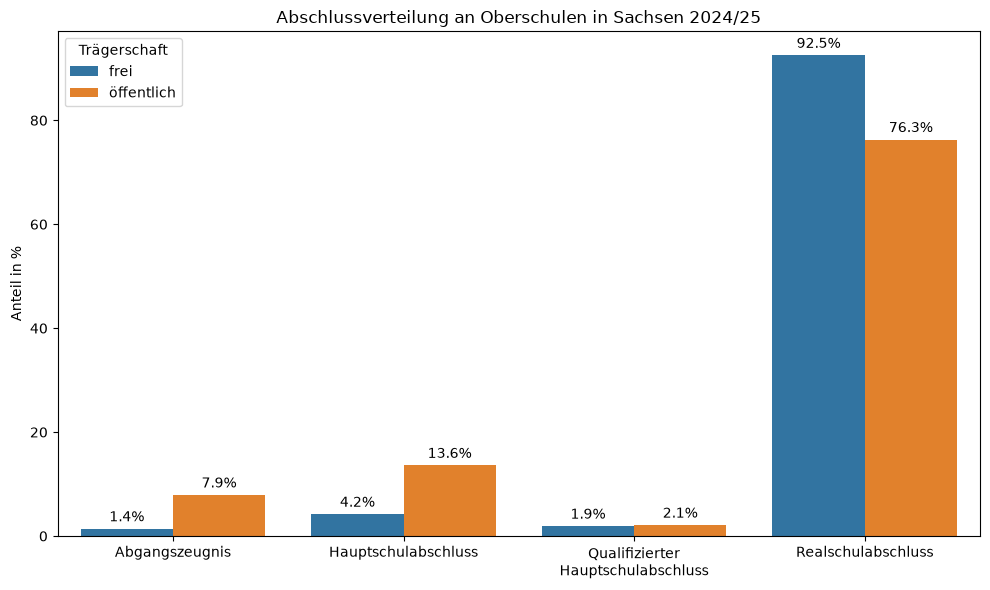

In [95]:
plot_daten["Abschluss"] = plot_daten["Abschluss"].replace(
    "Qualifizierter Hauptschulabschluss",
    "Qualifizierter\nHauptschulabschluss",
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=plot_daten,
    x="Abschluss",
    y="anteil_prozent",
    hue="traegerschaft",
    ax=ax,
)

ax.set_title("Abschlussverteilung an Oberschulen in Sachsen 2024/25")
ax.set_xlabel("")
ax.set_ylabel("Anteil in %")
ax.legend(title="Trägerschaft")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Prüfen, welche Vorjahre die Schuldatenbank bereitstellt. Für die zweite Teilaufgabe: Wie hat sich der Unterschied über die Zeit entwickelt?
Ergebnis: Die Schuldatenbank Sachsen stellt auf den aktuellen Schuldetailseiten Abschlussdaten für 2024/25 bereit; für 2025/26 und 2026/27 liegen noch keine entsprechenden Daten vor. Der vorhandene GENESIS-Datensatz enthält zwar historische Abschlussdaten nach Schulart, unterscheidet jedoch nicht zwischen öffentlicher und freier Trägerschaft. Eine historische Entwicklung der Abschlussunterschiede zwischen öffentlichen und freien Oberschulen lässt sich daher mit den bisher vorliegenden Daten nicht belastbar bestimmen.

In [96]:
institution_key = 4233037

url = (
    "https://schuldatenbank.sachsen.de/"
    f"index.php?id=110&institution_key={institution_key}"
)

with urlopen(url, timeout=10, context=context) as response:
    html = response.read().decode("utf-8")

baum = lxml_html.fromstring(html)

for link in baum.xpath('//a[starts-with(@href, "#tablist-2_tab-")]'):
    print(
        link.get("href"),
        "→",
        link.text_content().strip(),
    )

#tablist-2_tab-1 → 2026/27
#tablist-2_tab-2 → 2025/26
#tablist-2_tab-3 → 2024/25
